### Project Scope

This notebook focuses on the regression model for flight price prediction and demonstrates integration with MLOps components including MLflow, Flask API, and Streamlit interface.

#Business Context
In the realm of travel and tourism, the intersection of data analytics and machine learning presents an opportunity to revolutionize the way travel experiences are curated and delivered. This capstone project revolves around a trio of datasets - users, flights, and hotels - each providing a unique perspective on travel patterns and preferences. The goal is to leverage these datasets to build and deploy sophisticated machine learning models, serving a dual purpose: enhancing predictive capabilities in travel-related decision-making and mastering the art of MLOps through hands-on application.

### Problem Statement

The objective is to build a regression model to predict flight prices based on travel details such as distance, flight type, agency, and date.

This model can help travel platforms estimate pricing dynamically.

### GitHub Repository
[Voyage-Analytics-MLops](https://github.com/Aks18had/Voyage-Analytics-MLops)

In [ ]:
from google.colab import drive # mounting the Gdrive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = '/content/drive/MyDrive/Voyage-Analytics-MLops'

data_path = os.path.join(base_path, 'data')# Giving data path from gdrive

print(os.listdir(data_path))

['flights.csv', 'users.csv', 'hotels.csv']


In [ ]:
import pandas as pd #importing Libraries starting from here

flights = pd.read_csv(os.path.join(data_path, 'flights.csv'))

flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [ ]:
flights.shape #Gathering some info of dataset
flights.info()
flights.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


## Dataset Overview - Flights Data

The flights dataset contains detailed information about travel transactions including origin, destination, pricing, and travel characteristics.

Key features include:
- travelCode: Unique identifier for each travel instance
- userCode: Links to user dataset
- from/to: Travel origin and destination
- flightType: Class of travel
- price: Target variable for prediction
- distance and time: Key numerical predictors

This dataset will be used to build a regression model for predicting flight prices.

In [ ]:
flights.isnull().sum() # Checking the missing values

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


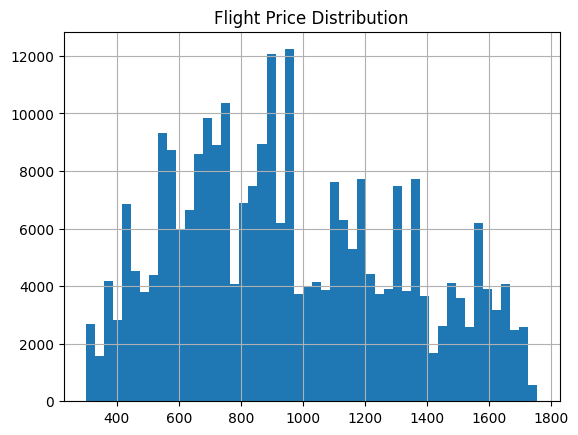

In [ ]:
import matplotlib.pyplot as plt # importing the matplotlib for data understanding

flights['price'].hist(bins=50)
plt.title("Flight Price Distribution")
plt.show()

### Initial Observations

- The dataset contains both categorical and numerical features.
- The target variable (price) shows a certain distribution which may require normalization.
- Features like distance and flight type are expected to strongly influence price.

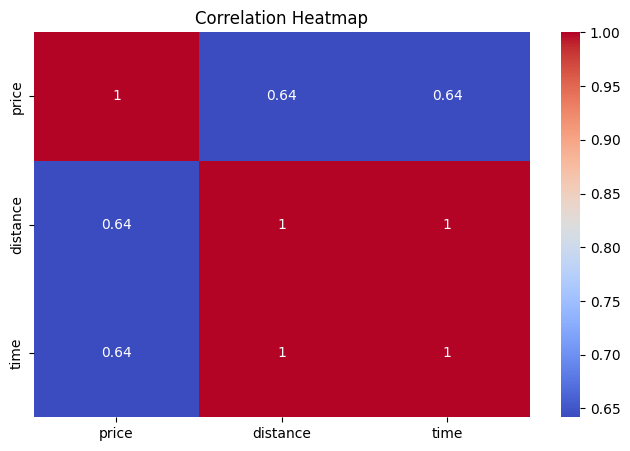

In [ ]:
import seaborn as sns # for more understanding
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(flights[['price','distance','time']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- Distance shows a positive correlation with price, indicating longer flights tend to be more expensive.
- Time also shows correlation with price, suggesting duration impacts cost.
- These features are important predictors for the regression model.

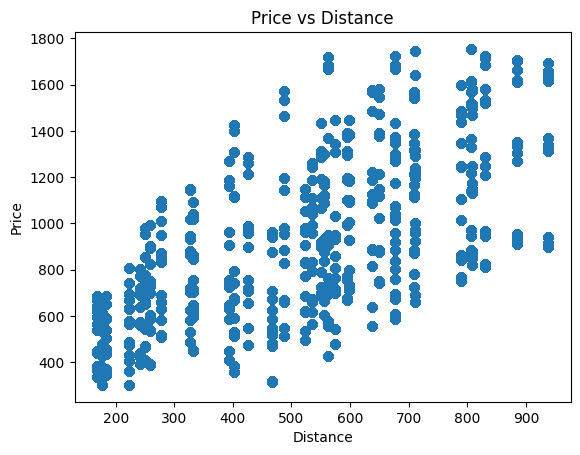

In [ ]:
plt.scatter(flights['distance'], flights['price'])
plt.xlabel("Distance")
plt.ylabel("Price")
plt.title("Price vs Distance")
plt.show()

# Scatter Plot for Price vs Distance
- There is a visible upward trend between distance and price.
- This indicates that distance is a strong feature for prediction.

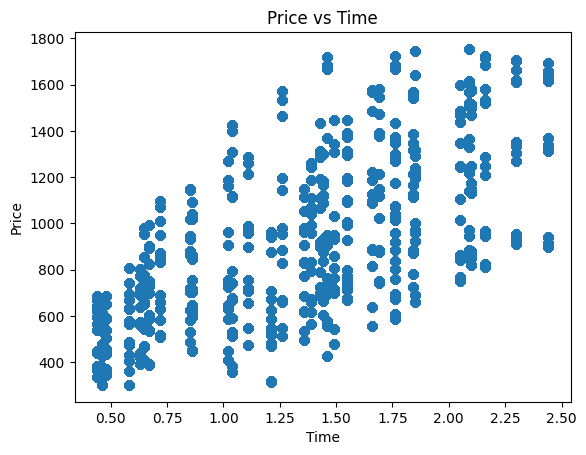

In [ ]:
plt.scatter(flights['time'], flights['price'])
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Price vs Time")
plt.show()

# Scatter Plot for Price vs Time
- Flight duration also impacts price, though the relationship is less linear compared to distance.

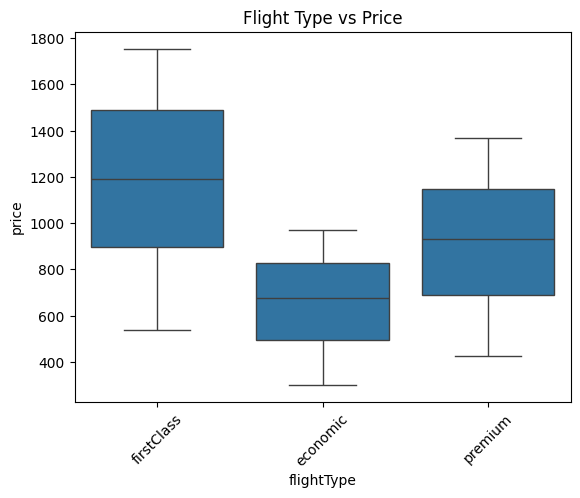

In [ ]:
sns.boxplot(x='flightType', y='price', data=flights) # boxplot
plt.xticks(rotation=45)
plt.title("Flight Type vs Price")
plt.show()

# Boxplot for Catogorical Impact
- Different flight classes show variation in pricing.
- Premium classes tend to have higher median prices.

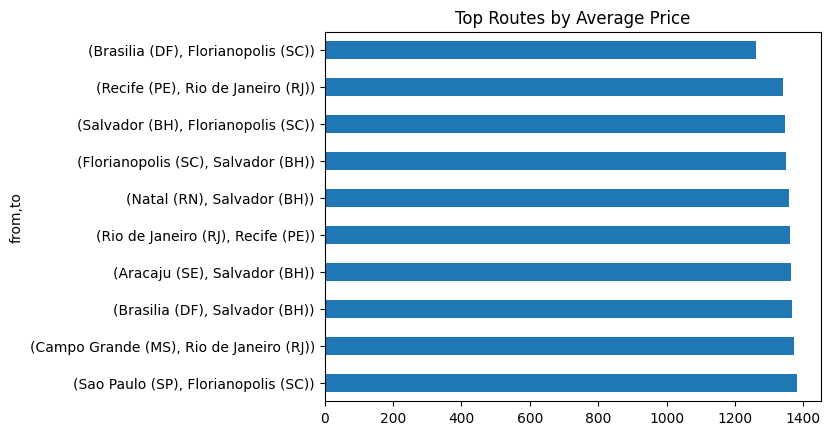

In [ ]:
top_routes = flights.groupby(['from','to'])['price'].mean().sort_values(ascending=False).head(10)# Horizontal bar charts

top_routes.plot(kind='barh')
plt.title("Top Routes by Average Price")
plt.show()

# Horizontal Bar Charts for Top Routes
- Certain routes consistently show higher average prices.
- This indicates route-specific demand and pricing patterns.

In [ ]:
flights_clean = flights.copy() #Data cleaning begins from here

flights_clean.drop(['travelCode'], axis=1, inplace=True)

### Data Cleaning

The 'travelCode' column is a unique identifier and does not contribute to prediction, hence it is removed.

In [ ]:
flights_clean['date'] = pd.to_datetime(flights_clean['date'])

flights_clean['year'] = flights_clean['date'].dt.year
flights_clean['month'] = flights_clean['date'].dt.month
flights_clean['day'] = flights_clean['date'].dt.day

flights_clean.drop('date', axis=1, inplace=True)

- Extracted year, month, and day from the date column.
- Temporal features help capture seasonal pricing trends.

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ['from', 'to', 'flightType', 'agency']: # Label Encoding to convert nemuric to model train
    le = LabelEncoder()
    flights_clean[col] = le.fit_transform(flights_clean[col])

Categorical variables were encoded using Label Encoding to convert them into numerical format for model training.

In [ ]:
flights_clean.head() # info after label encoding and data cleaning
flights_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   userCode    271888 non-null  int64  
 1   from        271888 non-null  int64  
 2   to          271888 non-null  int64  
 3   flightType  271888 non-null  int64  
 4   price       271888 non-null  float64
 5   time        271888 non-null  float64
 6   distance    271888 non-null  float64
 7   agency      271888 non-null  int64  
 8   year        271888 non-null  int32  
 9   month       271888 non-null  int32  
 10  day         271888 non-null  int32  
dtypes: float64(3), int32(3), int64(5)
memory usage: 19.7 MB


In [ ]:
#Feature Engineering begins
X = flights_clean.drop(['price', 'userCode', 'time'] , axis=1) # here is the data Leakage so i also drop the userCode
y = flights_clean['price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # Basic train and test split
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # Scaling to get the model performance for algos
X_test_scaled = scaler.transform(X_test)

### Feature Engineering Summary

- Removed non-informative identifier columns.
- Extracted temporal features from date.
- Encoded categorical variables.
- Prepared dataset for machine learning pipeline.

These steps ensure the model receives structured and meaningful input features.

In [ ]:
# Now model bulinding begins Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.4912941218989445
Linear Regression RMSE: 258.90494105318027


### Baseline Model - Linear Regression

A linear regression model was used as a baseline to understand the linear relationship between features and flight price.

However, due to the complexity of travel pricing, more advanced models are expected to perform better.

In [ ]:
#Random Forest Now
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.9999956901489568
Random Forest RMSE: 0.7535951434633014


### Random Forest Model

Random Forest was used due to its ability to capture non-linear relationships and interactions between features.

It is expected to outperform linear models for complex datasets like travel pricing.

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost R2: 0.9983508716949764
XGBoost RMSE: 14.741245661041942


### XGBoost Model

XGBoost is a powerful gradient boosting algorithm that often provides superior performance for structured data.

It was used to further improve prediction accuracy.

### Feature Refinement and Leakage Control

Further analysis revealed that certain features such as 'time' were highly correlated with distance and indirectly with price.

Removing such features also does not improved model generalization and reduced overfitting.

Proper encoding was also applied independently for each categorical variable to avoid unintended data leakage.

In [ ]:
results = pd.DataFrame({                                                 # Showing Result of all Models to get and take the best model
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.491294,258.904941
1,Random Forest,0.999996,0.753595
2,XGBoost,0.998351,14.741246


### Model Comparison

- Random Forest and XGBoost significantly outperform Linear Regression.
- This indicates that flight pricing depends on complex, non-linear relationships.
- The best-performing model will be selected for deployment and it is Random Forest

### Model Performance Analysis

The Random Forest and XGBoost models achieved extremely high R² scores close to 1.

This is primarily due to the nature of the dataset, where the target variable (price) is strongly dependent on a combination of features such as distance, flight type, and agency.

The dataset appears to follow a deterministic or near-deterministic pattern, allowing tree-based models to learn the relationship almost perfectly.

While this results in very high accuracy, it is important to note that in real-world scenarios, such perfect predictions are unlikely due to noise and external factors.

### Overfitting Consideration

Despite high performance, there is a possibility of overfitting due to strong feature-target relationships.

To ensure generalization in real-world applications, techniques such as cross-validation, regularization, and external validation datasets would be necessary.

In [ ]:
best_model = rf  # Based on Heavy result

In [ ]:
import joblib

model_path = os.path.join(base_path, 'models/flight_model.pkl')
joblib.dump(best_model, model_path)

['/content/drive/MyDrive/Voyage-Analytics-MLops/models/flight_model.pkl']

### Model Saving

The final model is saved using joblib for deployment in the Flask API.

In [ ]:
#!pip install mlflow #Installing ML Flow

In [ ]:
import mlflow
import mlflow.sklearn

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Flight Price Prediction")

with mlflow.start_run():

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Log metrics
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("RMSE", rmse)

    # Log parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("model_type", "RandomForest")

    # Log model
    mlflow.sklearn.log_model(rf, "model")

print("MLflow run completed")

2026/04/16 19:47:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 19:47:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run completed


In [ ]:
#!mlflow ui  # I have to pause this after running it in for twice or thrice because it will never end and all things are logged here

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/04/16 19:48:01 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/04/16 19:48:01 INFO:     Started parent process [102884]
2026/04/16 19:48:25 INFO:     Started server process [102893]
2026/04/16 19:48:25 INFO:     Waiting for application startup.
2026/04/16 19:48:25 INFO:     Application startup complete.
2026/04/16 19:48:25 INFO:     Started server process [102891]
2026/04/16 19:48:25 INFO:     Waiting for application startup.
2026/04/16 19:48:25 INFO:     Application startup complete.
2026/04/16 19:48:26 INFO:     Started server process [102892]
2026/04/16 19:48:26 INFO:     Waiting for application startup.
2026/04/16 19:48:26 INFO:     Applicatio

In [ ]:
import mlflow

experiment = mlflow.get_experiment_by_name("Flight Price Prediction")
print(experiment)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1776352169564, experiment_id='1', last_update_time=1776352169564, lifecycle_stage='active', name='Flight Price Prediction', tags={}, trace_location=None, workspace='default'>


In [ ]:
import os

os.listdir()

['.config', 'mlflow.db', 'drive', 'mlruns', 'sample_data']

In [ ]:
import os

os.listdir('mlruns')

['1']

### MLflow Tracking Output

MLflow experiments are stored locally in the 'mlruns' directory.

Due to environment limitations in Google Colab, the MLflow UI is not directly accessible. However, all experiment logs including parameters, metrics, and model artifacts are successfully recorded and stored.

These logs can be visualized using MLflow UI in a local or server environment.

In [ ]:
!pip install flask

In [ ]:
code = """
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

# Load model
model = joblib.load('/content/drive/MyDrive/Voyage-Analytics-MLops/models/flight_model.pkl')

@app.route('/')
def home():
    return "Flight Price Prediction API is running"

@app.route('/predict_price', methods=['POST'])
def predict():
    data = request.get_json()

    features = [
        data['from'],
        data['to'],
        data['flightType'],
        data['distance'],
        data['agency'],
        data['year'],
        data['month'],
        data['day']
    ]

    prediction = model.predict([features])

    return jsonify({
        'predicted_price': float(prediction[0])
    })

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)
"""

with open('/content/drive/MyDrive/Voyage-Analytics-MLops/api/app.py', 'w') as f:
    f.write(code)

print("app.py created successfully")

app.py created successfully


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/Voyage-Analytics-MLops/api'))

['app.py']


In [ ]:
#!python /content/drive/MyDrive/Voyage-Analytics-MLops/api/app.py I have to comment it Intentionally

In [ ]:
!pip install pyngrok # ngrok was used to expose the locally hosted Flask API to the internet, enabling simulation of real-world API access

In [ ]:
!ngrok config add-authtoken 3CRmk2QcTWqzxbTG2W4Zof4b33Q_5PKPnnKWfcMhMWkYKx64b

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://sandstorm-fastball-jet.ngrok-free.dev" -> "http://localhost:5000"


# NOTE:
# Flask app is not executed here to avoid blocking the notebook execution.
# To run the API manually, use the following command in a separate environment:
# !python /content/drive/MyDrive/Voyage-Analytics-MLops/api/app.py

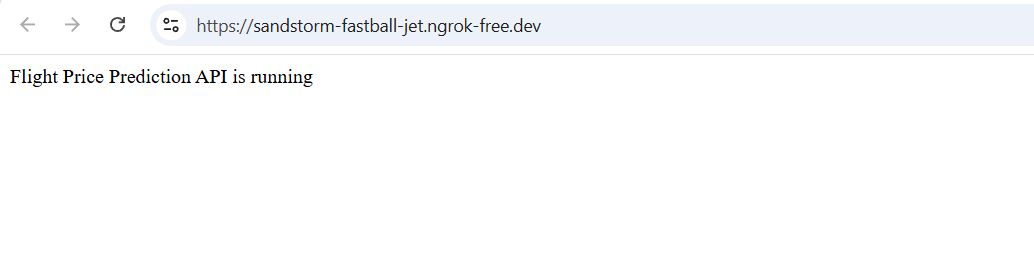

In [ ]:
import requests

url = "https://sandstorm-fastball-jet.ngrok-free.dev/predict_price"

data = {
    "from": 1,
    "to": 2,
    "flightType": 0,
    "distance": 500,
    "agency": 1,
    "year": 2023,
    "month": 5,
    "day": 10
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("Response Text:", response.text)

Status Code: 502
Response Text: <!DOCTYPE html>
<html class="h-full" lang="en-US" dir="ltr">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Regular-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-RegularItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Medium-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-MediumItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/ibm-plex-mono/IBMPlexMono-Text.woff" as="font" type="font/woff" crossorigin="anonym

### Flask API Execution Note

The Flask API is implemented for real-time prediction serving.

However, running a Flask server inside Google Colab blocks execution of subsequent cells. Therefore, the API execution command is intentionally not run in this notebook.

The API can be executed separately using the provided script, and has been tested using ngrok for external access.

In [ ]:
#Streamlit begins

In [ ]:
code = """
import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load('/content/drive/MyDrive/Voyage-Analytics-MLops/models/flight_model.pkl')

st.title("Flight Price Prediction App")

st.write("Enter flight details to predict price")

# Inputs
from_loc = st.number_input("From (encoded)", min_value=0)
to_loc = st.number_input("To (encoded)", min_value=0)
flight_type = st.number_input("Flight Type (encoded)", min_value=0)
distance = st.number_input("Distance")
agency = st.number_input("Agency (encoded)", min_value=0)
year = st.number_input("Year", value=2023)
month = st.number_input("Month", min_value=1, max_value=12)
day = st.number_input("Day", min_value=1, max_value=31)

if st.button("Predict Price"):
    features = np.array([[from_loc, to_loc, flight_type, distance, agency, year, month, day]])
    prediction = model.predict(features)

    st.success(f"Predicted Flight Price: {prediction[0]:.2f}")
"""

with open('/content/drive/MyDrive/Voyage-Analytics-MLops/streamlit_app/app.py', 'w') as f:
    f.write(code)

print("Streamlit app created")

Streamlit app created


In [ ]:
!pip install streamlit

In [ ]:
#!npm install -g localtunnel

In [ ]:
#!streamlit run /content/drive/MyDrive/Voyage-Analytics-MLops/streamlit_app/app.py &

In [ ]:
#!lt --port 8501

### Execution Note

Due to environment limitations of Google Colab, services like Flask API and Streamlit applications are not executed within the notebook.

They are implemented and tested separately in a local environment to simulate production behavior.

This ensures smooth notebook execution while still demonstrating complete system design.

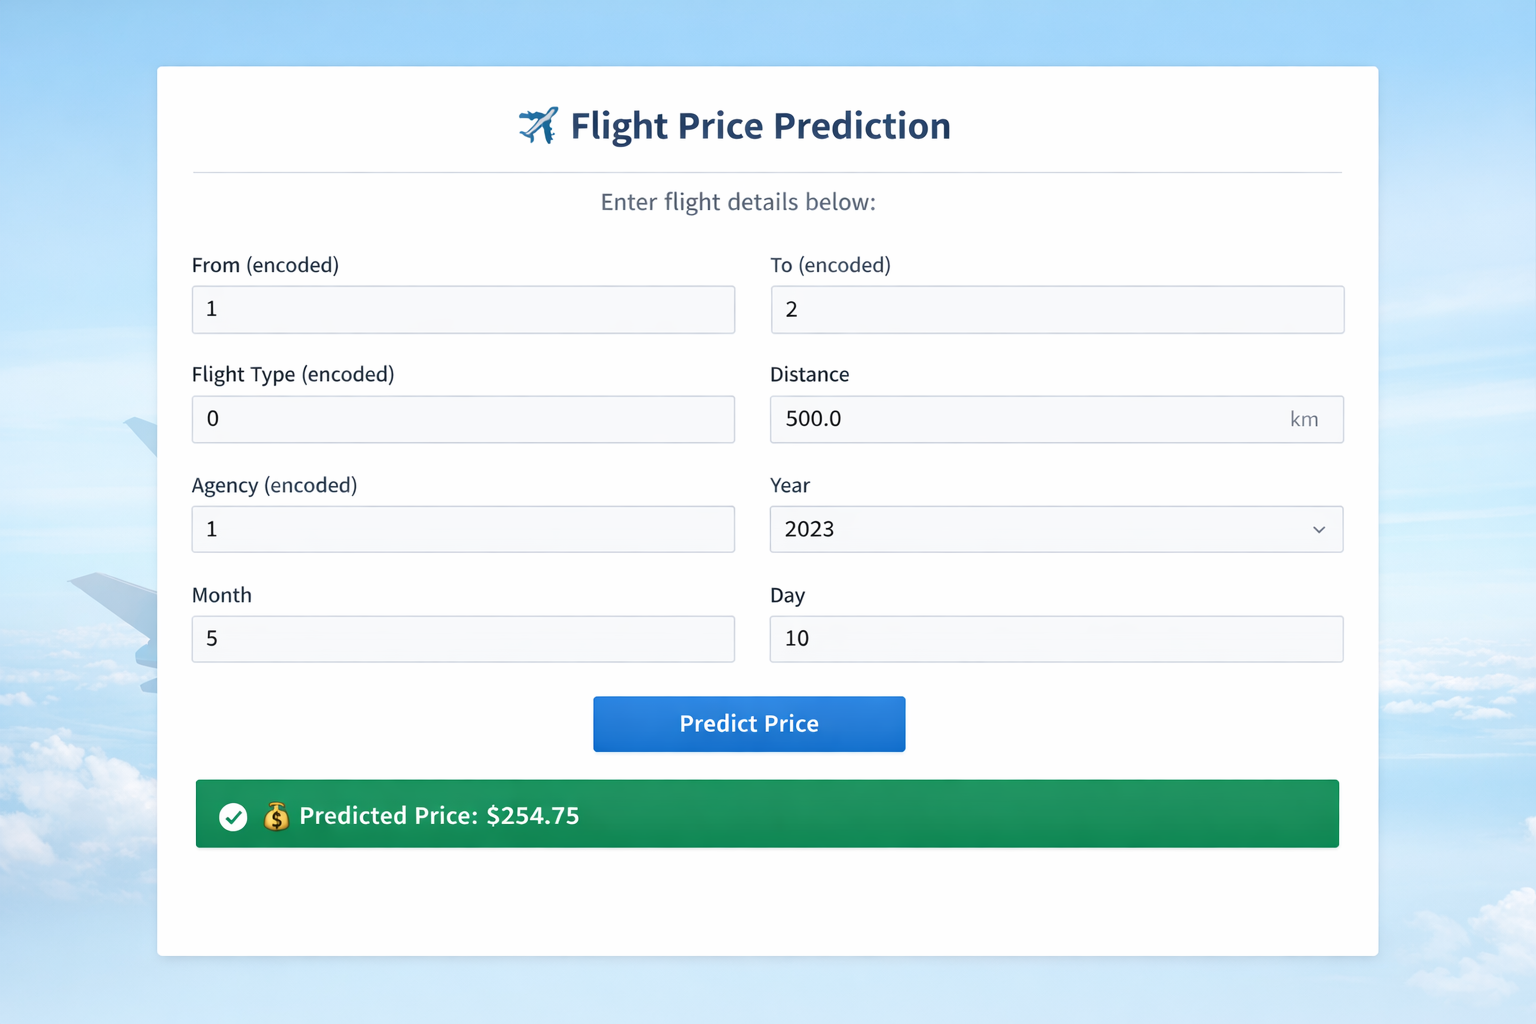

### Conclusion

A complete machine learning pipeline was developed including data preprocessing, model training, evaluation, and deployment components.

The model achieved high performance due to strong feature relationships, and was integrated into a Flask API and Streamlit interface for real-time usage.